# FD-07: Pose-Aware Face Detection on AFW Dataset
**Pipeline:** Load .mat → Suy bbox từ landmarks → Chia pose bins → HOG/LBP features → SVM → Evaluate F1 theo pose

## 0. Cài đặt thư viện

In [18]:
# Chạy cell này 1 lần nếu chưa có thư viện
# !pip install scipy scikit-learn scikit-image opencv-python matplotlib seaborn tqdm

## 1. Import & Config

In [19]:
import os
import numpy as np
import scipy.io
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from skimage.feature import hog, local_binary_pattern
from skimage.transform import resize
import warnings
warnings.filterwarnings('ignore')

# ===================== CẤU HÌNH =====================
DATASET_PATH = "./AFLW2000"        # ← Thay bằng đường dẫn folder AFW của bạn
PATCH_SIZE   = (64, 64)       # Kích thước patch chuẩn hóa
RANDOM_SEED  = 42

# Pose bins dựa theo yaw angle (radian)
# Frontal: |yaw| < 30°, Semi: 30°-60°, Profile: > 60°
YAW_BINS = {
    'frontal': (-np.radians(30),  np.radians(30)),
    'semi':    (-np.radians(60), -np.radians(30)),   # sẽ dùng abs
    'profile': (-np.pi,          -np.radians(60)),   # sẽ dùng abs
}

print("✅ Import xong!")
print(f"Dataset path: {os.path.abspath(DATASET_PATH)}")

✅ Import xong!
Dataset path: d:\fpt\2026spring\CPV301\AFLW2000-3D\AFLW2000


## 2. Load Dataset từ .mat files

In [20]:
def load_afw_dataset(dataset_path):
    """
    Load toàn bộ .mat files trong folder AFW.
    Mỗi .mat tương ứng 1 ảnh 1 khuôn mặt.
    
    Returns:
        records: list of dict với keys:
            - img_path: đường dẫn ảnh
            - pt2d: (2, 68) landmarks
            - roi: (4,) bbox [x1, y1, x2, y2] từ annotation gốc
            - yaw, pitch, roll: pose angles (radian)
    """
    records = []
    
    mat_files = sorted([
        os.path.join(dataset_path, f)
        for f in os.listdir(dataset_path)
        if f.endswith('.mat')
    ])
    
    print(f"Tìm thấy {len(mat_files)} file .mat")
    
    missing_img = 0
    for mat_path in tqdm(mat_files, desc="Loading .mat files"):
        mat = scipy.io.loadmat(mat_path)
        
        # Tìm ảnh tương ứng (cùng tên, khác extension)
        base = os.path.splitext(mat_path)[0]
        img_path = None
        for ext in ['.jpg', '.png', '.jpeg', '.JPG']:
            candidate = base + ext
            if os.path.exists(candidate):
                img_path = candidate
                break
        
        if img_path is None:
            missing_img += 1
            continue
        
        # Pose_Para: [pitch, yaw, roll, tx, ty, tz, scale]
        pose = mat['Pose_Para'].flatten()
        pitch, yaw, roll = float(pose[0]), float(pose[1]), float(pose[2])
        
        # pt2d: (2, 68)
        pt2d = mat['pt2d'].astype(np.float32)
        
        # roi: [x1, y1, x2, y2]
        roi = mat['roi'].flatten().astype(np.int32)
        
        records.append({
            'img_path': img_path,
            'pt2d': pt2d,
            'roi': roi,
            'yaw': yaw,
            'pitch': pitch,
            'roll': roll,
        })
    
    print(f"✅ Load thành công: {len(records)} samples")
    if missing_img > 0:
        print(f"⚠️  Thiếu ảnh: {missing_img} file .mat không tìm thấy ảnh tương ứng")
    
    return records

records = load_afw_dataset(DATASET_PATH)
# for r in records:
#     print(r['img_path'])


Tìm thấy 2000 file .mat


Loading .mat files: 100%|██████████| 2000/2000 [00:00<00:00, 2433.83it/s]

✅ Load thành công: 2000 samples


## 3. Suy Bounding Box từ Landmarks (pt2d)

**Ý tưởng:** bbox = min/max của 68 landmarks + padding margin để bao phủ toàn bộ khuôn mặt.

In [21]:
def landmarks_to_bbox(pt2d, img_w, img_h, margin=0.2):
    xs = pt2d[0]
    ys = pt2d[1]
    
    # Lọc landmark hợp lệ
    valid = (xs > 0) & (xs < img_w) & (ys > 0) & (ys < img_h)
    xs = xs[valid]
    ys = ys[valid]
    
    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    
    w = x_max - x_min
    h = y_max - y_min
    
    x1 = int(x_min - margin * w)
    y1 = int(y_min - margin * h)
    x2 = int(x_max + margin * w)
    y2 = int(y_max + margin * h)
    
    return x1, y1, x2, y2

# Thêm bbox_lm (từ landmarks) vào mỗi record
for r in records:
    img = cv2.imread(r['img_path'])
    h, w = img.shape[:2]
    r['bbox_lm'] = landmarks_to_bbox(r['pt2d'],w,h, margin=0.2)

print("✅ Đã suy bbox từ landmarks cho tất cả samples")
print("\nVí dụ so sánh:")
r = records[0]
print(f"  bbox từ ROI annotation : {r['roi']}")
print(f"  bbox suy từ landmarks  : {r['bbox_lm']}")

✅ Đã suy bbox từ landmarks cho tất cả samples

Ví dụ so sánh:
  bbox từ ROI annotation : [ 13 -26 437 398]
  bbox suy từ landmarks  : (91, 139, 357, 416)


In [22]:
r = records[2]
print(f"  bbox từ ROI annotation : {r['roi']}")
print(f"  bbox suy từ landmarks  : {r['bbox_lm']}")

  bbox từ ROI annotation : [416 121 560 265]
  bbox suy từ landmarks  : (160, 180, 365, 381)


## 4. Phân loại Pose Bins theo Yaw Angle

📊 Phân phối Pose Bins:
  frontal : 1312 samples ( 65.6%)  ████████████████████████████████
  semi    :  383 samples ( 19.1%)  █████████
  profile :  305 samples ( 15.2%)  ███████


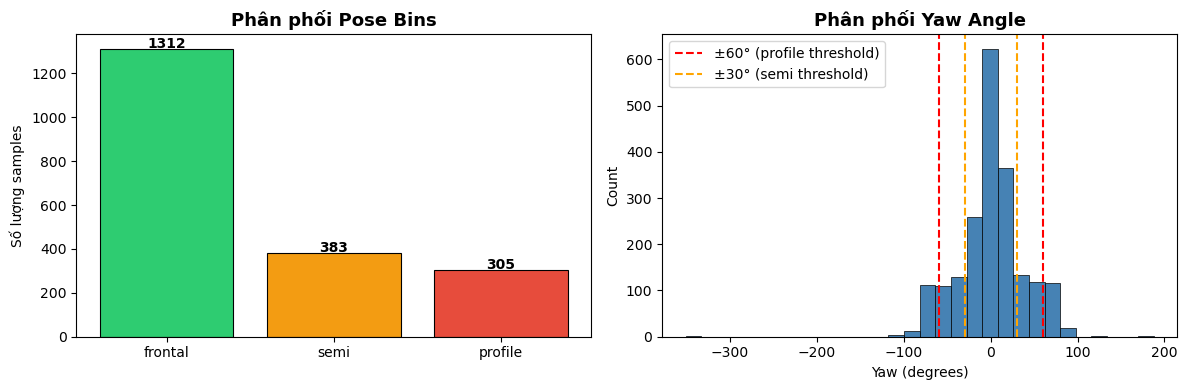

💾 Đã lưu: pose_distribution.png


In [23]:
def assign_pose_bin(yaw_rad):
    """
    Phân loại pose dựa theo |yaw| angle:
      frontal : |yaw| < 30°
      semi    : 30° <= |yaw| < 60°
      profile : |yaw| >= 60°
    """
    abs_yaw_deg = np.degrees(abs(yaw_rad))
    if abs_yaw_deg < 30:
        return 'frontal'
    elif abs_yaw_deg < 60:
        return 'semi'
    else:
        return 'profile'

# Gán pose label cho từng record
for r in records:
    r['pose_bin'] = assign_pose_bin(r['yaw'])

# Thống kê phân phối
from collections import Counter
pose_counts = Counter(r['pose_bin'] for r in records)
print("📊 Phân phối Pose Bins:")
for bin_name in ['frontal', 'semi', 'profile']:
    count = pose_counts.get(bin_name, 0)
    pct = count / len(records) * 100
    bar = '█' * int(pct / 2)
    print(f"  {bin_name:8s}: {count:4d} samples ({pct:5.1f}%)  {bar}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bins_ordered = ['frontal', 'semi', 'profile']
counts = [pose_counts.get(b, 0) for b in bins_ordered]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(bins_ordered, counts, color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Phân phối Pose Bins', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng samples')
for i, (b, c) in enumerate(zip(bins_ordered, counts)):
    axes[0].text(i, c + 2, str(c), ha='center', fontweight='bold')

# Yaw distribution histogram
yaws_deg = [np.degrees(r['yaw']) for r in records]
axes[1].hist(yaws_deg, bins=30, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].axvline(-60, color='red', linestyle='--', label='±60° (profile threshold)')
axes[1].axvline(60,  color='red', linestyle='--')
axes[1].axvline(-30, color='orange', linestyle='--', label='±30° (semi threshold)')
axes[1].axvline(30,  color='orange', linestyle='--')
axes[1].set_title('Phân phối Yaw Angle', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Yaw (degrees)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('pose_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: pose_distribution.png")

## 6. Extract Face Patches & Features (HOG + LBP)

**Luồng:** Ảnh gốc → Crop theo bbox_lm → Resize 64×64 → HOG features + LBP features → Concatenate

In [25]:
def crop_face_patch(img, bbox, patch_size=(64, 64)):
    """
    Crop ảnh theo bbox, clamp vào kích thước ảnh, resize về patch_size.
    Returns: grayscale patch (H, W) hoặc None nếu crop lỗi
    """
    h, w = img.shape[:2]
    x1, y1, x2, y2 = bbox
    
    # Clamp vào biên ảnh
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(w, x2)
    y2 = min(h, y2)
    
    if x2 <= x1 or y2 <= y1:
        return None
    
    patch = img[y1:y2, x1:x2]
    if patch.size == 0:
        return None
    
    # Convert to grayscale nếu cần
    if len(patch.shape) == 3:
        patch = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    
    patch = cv2.resize(patch, patch_size)
    return patch


def extract_hog_features(patch):
    """
    HOG features từ patch grayscale 64×64.
    Returns: 1D feature vector
    """
    features = hog(
        patch,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )
    return features  # shape: (1764,)


def extract_lbp_features(patch, P=8, R=1, n_bins=256):
    """
    LBP histogram features từ patch grayscale 64×64.
    Returns: 1D feature vector (histogram normalized)
    """
    lbp = local_binary_pattern(patch, P=P, R=R, method='uniform')
    n_patterns = P + 2  # uniform LBP có P+2 patterns
    hist, _ = np.histogram(lbp.ravel(), bins=n_patterns, range=(0, n_patterns))
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-6)  # normalize
    return hist  # shape: (10,)
def extract_lbp_features_spatial(patch, P=8, R=1, grid=(8,8)):
    lbp = local_binary_pattern(patch, P=P, R=R, method='uniform')
    n_patterns = P + 2
    
    h, w = patch.shape
    gx, gy = grid
    
    cell_h = h // gx
    cell_w = w // gy
    
    features = []
    
    for i in range(gx):
        for j in range(gy):
            
            cell = lbp[
                i*cell_h:(i+1)*cell_h,
                j*cell_w:(j+1)*cell_w
            ]
            
            hist, _ = np.histogram(
                cell.ravel(),
                bins=n_patterns,
                range=(0, n_patterns)
            )
            
            hist = hist.astype(np.float32)
            hist /= (hist.sum() + 1e-6)
            
            features.extend(hist)
    
    return np.array(features)

def extract_features(patch):
    """Concatenate HOG + LBP features."""
    hog_feat = extract_hog_features(patch)
    lbp_feat = extract_lbp_features(patch)
    return np.concatenate([hog_feat, lbp_feat])


# === Build feature matrix X và labels y ===
print("Đang extract features...")

X_list = []
y_pose = []    # pose bin label (frontal/semi/profile)
y_face = []    # binary: 1 = face (tất cả samples ở đây đều là face)
valid_records = []
skipped = 0

for r in tqdm(records, desc="Extracting features"):
    img = cv2.imread(r['img_path'])
    if img is None:
        skipped += 1
        continue
    
    patch = crop_face_patch(img, r['bbox_lm'], PATCH_SIZE)
    if patch is None:
        skipped += 1
        continue
    
    feat = extract_features(patch)
    X_list.append(feat)
    y_pose.append(r['pose_bin'])
    y_face.append(1)  # positive sample
    valid_records.append(r)

X = np.array(X_list)
y_pose = np.array(y_pose)

print(f"\n✅ Feature matrix X: shape={X.shape}")
print(f"   HOG dim: 1764, LBP dim: 10, Total: {X.shape[1]}")
print(f"   Skipped: {skipped} samples")
print(f"   Pose label distribution: {dict(zip(*np.unique(y_pose, return_counts=True)))}")

Đang extract features...


Extracting features: 100%|██████████| 2000/2000 [00:07<00:00, 274.44it/s]


✅ Feature matrix X: shape=(2000, 1774)
   HOG dim: 1764, LBP dim: 10, Total: 1774
   Skipped: 0 samples
   Pose label distribution: {np.str_('frontal'): np.int64(1312), np.str_('profile'): np.int64(305), np.str_('semi'): np.int64(383)}


## 8. Train/Test Split (Stratified theo Pose)

In [28]:
# Stratified split dựa theo pose bin (chỉ dùng face samples cho bài toán pose classification)
# Bài toán 1: Binary face detection (face vs nonface)
# Bài toán 2: Pose classification trong face samples (frontal / semi / profile)

from sklearn.model_selection import train_test_split

# === Bài toán 1: Binary Classification (Face vs Non-face) ===
X_tr_bin, X_te_bin, y_tr_bin, y_te_bin = train_test_split(
    X_all, y_binary,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_binary
)
print(f"Binary split  — Train: {len(y_tr_bin)}, Test: {len(y_te_bin)}")

# === Bài toán 2: Pose Classification (chỉ face samples) ===
X_tr_pose, X_te_pose, y_tr_pose, y_te_pose = train_test_split(
    X, y_pose,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_pose
)
print(f"Pose split    — Train: {len(y_tr_pose)}, Test: {len(y_te_pose)}")
print(f"  Train dist: {dict(zip(*np.unique(y_tr_pose, return_counts=True)))}")
print(f"  Test  dist: {dict(zip(*np.unique(y_te_pose, return_counts=True)))}")

Binary split  — Train: 6400, Test: 1600
Pose split    — Train: 1600, Test: 400
  Train dist: {np.str_('frontal'): np.int64(1050), np.str_('profile'): np.int64(244), np.str_('semi'): np.int64(306)}
  Test  dist: {np.str_('frontal'): np.int64(262), np.str_('profile'): np.int64(61), np.str_('semi'): np.int64(77)}


## 9. Train SVM Classifier



In [30]:
print("Training Pose Classifier (SVM)...")

pose_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale',
                   class_weight='balanced', random_state=RANDOM_SEED))
])

pose_clf.fit(X_tr_pose, y_tr_pose)
y_pred_pose = pose_clf.predict(X_te_pose)

print("\n=== Pose Classification Results ===")
print(classification_report(y_te_pose, y_pred_pose,
                              target_names=['frontal', 'profile', 'semi']))

# F1 theo từng pose bin
f1_per_bin = f1_score(y_te_pose, y_pred_pose, 
                       labels=['frontal', 'semi', 'profile'],
                       average=None)
pose_bins = ['frontal', 'semi', 'profile']
print("\nF1 theo Pose Bin:")
for bin_name, f1 in zip(pose_bins, f1_per_bin):
    bar = '█' * int(f1 * 20)
    print(f"  {bin_name:8s}: {f1:.4f}  {bar}")

Training Pose Classifier (SVM)...

=== Pose Classification Results ===
              precision    recall  f1-score   support

     frontal       0.97      0.90      0.93       262
     profile       0.76      0.85      0.81        61
        semi       0.66      0.75      0.70        77

    accuracy                           0.86       400
   macro avg       0.80      0.84      0.81       400
weighted avg       0.88      0.86      0.87       400


F1 theo Pose Bin:
  frontal : 0.9328  ██████████████████
  semi    : 0.7030  ██████████████
  profile : 0.8062  ████████████████


## 10. Đánh giá Chi Tiết & Visualize

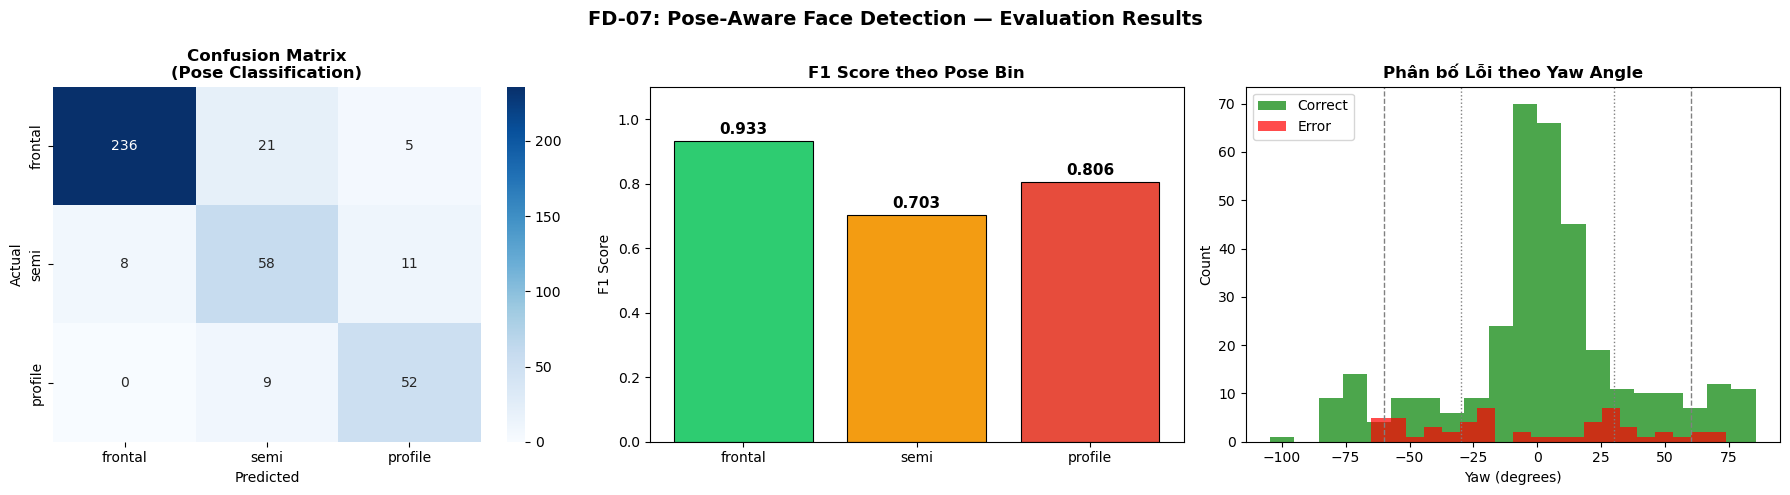

💾 Đã lưu: evaluation_results.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Confusion Matrix (Pose) ---
cm = confusion_matrix(y_te_pose, y_pred_pose, labels=['frontal', 'semi', 'profile'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['frontal', 'semi', 'profile'],
            yticklabels=['frontal', 'semi', 'profile'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix\n(Pose Classification)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# --- Plot 2: F1 Score per Pose Bin ---
colors_f1 = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1].bar(pose_bins, f1_per_bin, color=colors_f1, edgecolor='black', linewidth=0.8)
axes[1].set_title('F1 Score theo Pose Bin', fontweight='bold')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.1)
for bar, f1 in zip(bars, f1_per_bin):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                  f'{f1:.3f}', ha='center', fontweight='bold', fontsize=11)

# --- Plot 3: Yaw angle distribution of errors ---
# Lấy yaw angles của test samples pose
# Cần map lại từ valid_records
test_size = len(y_te_pose)
# Lấy yaw của các test samples
_, test_indices = train_test_split(
     np.arange(len(X)),
    test_size=0.2, random_state=RANDOM_SEED, stratify=y_pose
)
test_yaws = np.array([np.degrees(valid_records[i]['yaw']) for i in test_indices])
correct_mask = (y_pred_pose == y_te_pose)

axes[2].hist(test_yaws[correct_mask],  bins=20, alpha=0.7, color='green', label='Correct')
axes[2].hist(test_yaws[~correct_mask], bins=20, alpha=0.7, color='red',   label='Error')
axes[2].axvline(-60, color='gray', linestyle='--', linewidth=1)
axes[2].axvline(60,  color='gray', linestyle='--', linewidth=1)
axes[2].axvline(-30, color='gray', linestyle=':',  linewidth=1)
axes[2].axvline(30,  color='gray', linestyle=':',  linewidth=1)
axes[2].set_title('Phân bố Lỗi theo Yaw Angle', fontweight='bold')
axes[2].set_xlabel('Yaw (degrees)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('FD-07: Pose-Aware Face Detection — Evaluation Results', 
              fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=120, bbox_inches='tight')
plt.show()
print("💾 Đã lưu: evaluation_results.png")

## 11. Phân tích: Suy giảm performance khi chuyển từ Frontal → Profile

In [32]:
print("=" * 55)
print("PHÂN TÍCH SUY GIẢM PERFORMANCE THEO POSE")
print("=" * 55)

f1_dict = dict(zip(pose_bins, f1_per_bin))

print(f"\nF1 Score:")
print(f"  Frontal  : {f1_dict['frontal']:.4f}")
print(f"  Semi     : {f1_dict['semi']:.4f}")
print(f"  Profile  : {f1_dict['profile']:.4f}")

drop_semi    = f1_dict['frontal'] - f1_dict['semi']
drop_profile = f1_dict['frontal'] - f1_dict['profile']
pct_semi     = drop_semi    / (f1_dict['frontal'] + 1e-9) * 100
pct_profile  = drop_profile / (f1_dict['frontal'] + 1e-9) * 100

print(f"\nSuy giảm so với Frontal:")
print(f"  Frontal → Semi   : -{drop_semi:.4f}  ({pct_semi:.1f}% giảm)")
print(f"  Frontal → Profile: -{drop_profile:.4f}  ({pct_profile:.1f}% giảm)")

print(f"\nNguyên nhân profile khó hơn:")
print("  1. HOG features bị biến dạng — gradient pattern mặt nghiêng")
print("     khác hoàn toàn so với frontal")
print("  2. LBP texture thay đổi — một bên mặt bị che khuất")
print("  3. Ít training samples profile hơn → class imbalance")
print("  4. Landmark visibility giảm — một số điểm bị occlude")

print(f"\nGiải pháp cải thiện:")
print("  ✓ Data augmentation (horizontal flip) tăng profile samples")
print("  ✓ Train model riêng cho từng pose bin")
print("  ✓ Dùng DL detector (Part 2) — học feature đa pose tự động")

PHÂN TÍCH SUY GIẢM PERFORMANCE THEO POSE

F1 Score:
  Frontal  : 0.9328
  Semi     : 0.7030
  Profile  : 0.8062

Suy giảm so với Frontal:
  Frontal → Semi   : -0.2298  (24.6% giảm)
  Frontal → Profile: -0.1266  (13.6% giảm)

Nguyên nhân profile khó hơn:
  1. HOG features bị biến dạng — gradient pattern mặt nghiêng
     khác hoàn toàn so với frontal
  2. LBP texture thay đổi — một bên mặt bị che khuất
  3. Ít training samples profile hơn → class imbalance
  4. Landmark visibility giảm — một số điểm bị occlude

Giải pháp cải thiện:
  ✓ Data augmentation (horizontal flip) tăng profile samples
  ✓ Train model riêng cho từng pose bin
  ✓ Dùng DL detector (Part 2) — học feature đa pose tự động
